In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('data/supermarket_sales.csv')

# Show the first 5 rows
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
# Check the structure and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [5]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Convert Date to proper datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Quick look at the date range
print("Date range:", df['Date'].min(), "to", df['Date'].max())

Duplicate rows: 0
Date range: 2019-01-01 00:00:00 to 2019-03-30 00:00:00


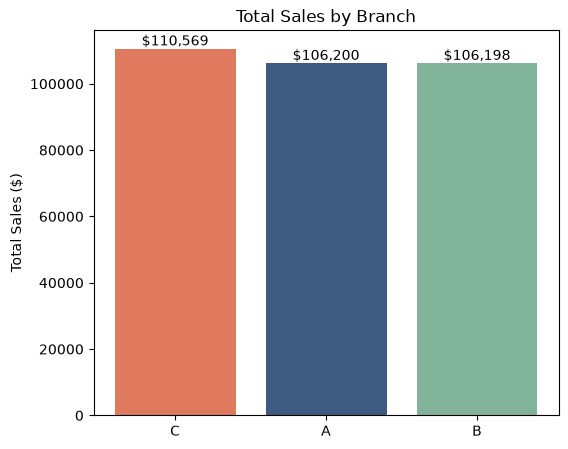

Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Total, dtype: float64


In [6]:
# Total sales by branch
branch_sales = df.groupby('Branch')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(6, 5))
bars = plt.bar(branch_sales.index, branch_sales.values, color=['#E07A5F', '#3D5A80', '#81B29A'])

plt.title('Total Sales by Branch')
plt.ylabel('Total Sales ($)')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'${height:,.0f}', ha='center', va='bottom')

plt.show()

print(branch_sales)

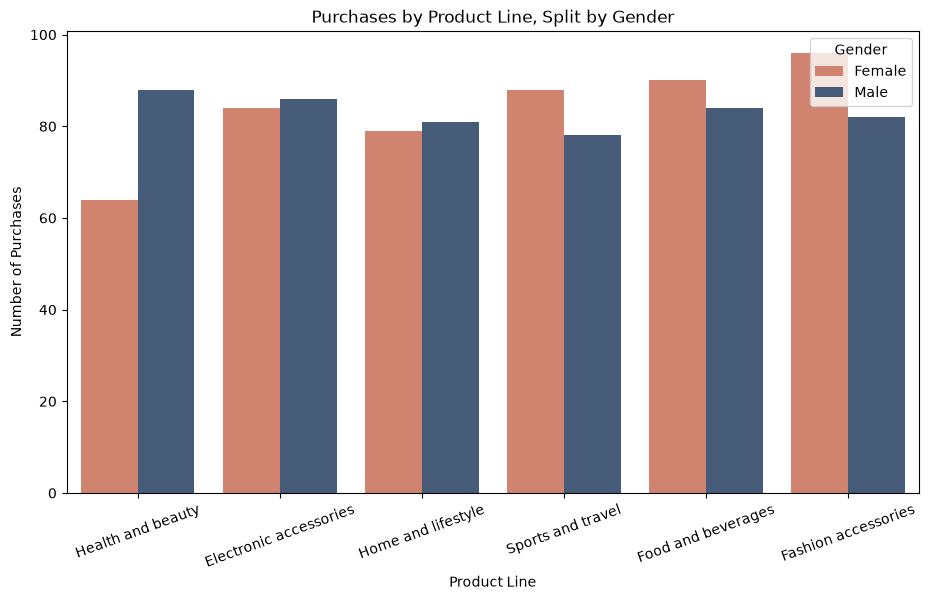

In [7]:
plt.figure(figsize=(11, 6))
sns.countplot(data=df, x='Product line', hue='Gender', palette=['#E07A5F', '#3D5A80'])

plt.title('Purchases by Product Line, Split by Gender')
plt.xlabel('Product Line')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=20)
plt.legend(title='Gender')
plt.show()

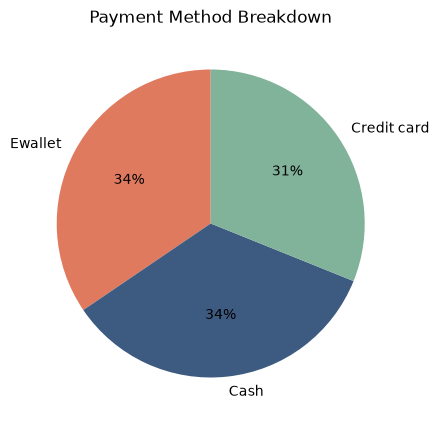

Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


In [8]:
plt.figure(figsize=(7, 5))
payment_counts = df['Payment'].value_counts()

plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.0f%%', startangle=90,
        colors=['#E07A5F', '#3D5A80', '#81B29A'])

plt.title('Payment Method Breakdown')
plt.show()

print(payment_counts)

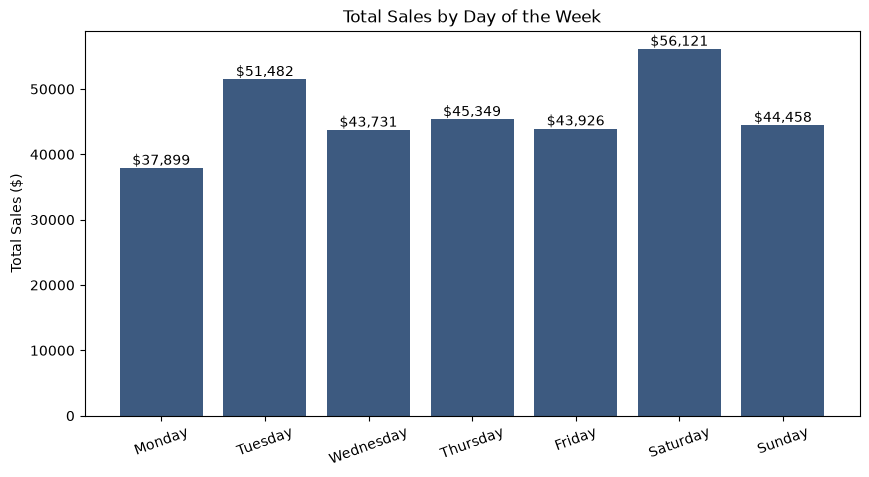

Day of Week
Monday       37899.0780
Tuesday      51482.2455
Wednesday    43731.1350
Thursday     45349.2480
Friday       43926.3405
Saturday     56120.8095
Sunday       44457.8925
Name: Total, dtype: float64


In [9]:
# Extract day of week from the Date column
df['Day of Week'] = df['Date'].dt.day_name()

# Order the days properly (Mon-Sun instead of alphabetical)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sales = df.groupby('Day of Week')['Total'].sum().reindex(day_order)

plt.figure(figsize=(10, 5))
bars = plt.bar(daily_sales.index, daily_sales.values, color='#3D5A80')

plt.title('Total Sales by Day of the Week')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=20)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'${height:,.0f}', ha='center', va='bottom')

plt.show()

print(daily_sales)